## Project Description

This project focuses on applying **supervised machine learning techniques** to the Breast Cancer Wisconsin dataset available in Scikit-learn. The objective is to build predictive models capable of classifying tumor diagnoses as malignant or benign based on a set of medical characteristics extracted from breast mass measurements.

The project covers the complete machine learning workflow, including data preparation, feature analysis, model training, prediction generation, and performance evaluation. Two classification algorithms, **Logistic Regression** and **Random Forest**, are implemented and compared using classification metrics, confusion matrices, and ROC curves to identify the model with the best predictive performance.

---

## Objectives

### General Objective

Develop and evaluate machine learning classification models to predict breast cancer diagnosis using clinical and morphological features extracted from medical data.

### Specific Objectives

- Load and prepare the dataset for machine learning analysis.
- Explore the characteristics of the data and identify the target variable and predictive features.
- Split the dataset into training and testing subsets to ensure an unbiased evaluation process.
- Apply feature scaling techniques to improve model performance and stability.
- Train a **Logistic Regression** model as a baseline classification algorithm.
- Train a **Random Forest** model to capture more complex relationships between variables.
- Generate predictions and class probabilities for both models.
- Evaluate model performance using confusion matrices and classification metrics.
- Compare the discriminative power of the models through ROC curves and AUC scores.
- Identify the model that provides the best balance between accuracy, sensitivity, and specificity.

---

## Machine Learning Skills Demonstrated

- Data Preparation and Preprocessing
- Train-Test Split Strategy
- Feature Scaling with StandardScaler
- Binary Classification
- Logistic Regression
- Random Forest Classification
- Model Training and Prediction
- Model Performance Evaluation
- Confusion Matrix Analysis
- ROC Curve Analysis
- AUC Score Interpretation
- Model Comparison and Selection
- Machine Learning Fundamentals
- Predictive Analytics

---

## Expected Outcomes

- Build reliable models capable of classifying breast cancer cases with high accuracy.
- Compare the strengths and limitations of Logistic Regression and Random Forest.
- Understand how evaluation metrics support decision-making in classification problems.
- Demonstrate practical knowledge of the end-to-end machine learning workflow, from data preparation to model evaluation.

### Data Loading and Preparation

First, we will simulate the loading of a dataset for a classification task. The **Breast Cancer** dataset from `sklearn` will be used as an example. Next, the data will be split into **training** and **testing** sets to enable proper model training and evaluation.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Cargar un conjunto de datos de ejemplo (Cáncer de Mama de sklearn)
data = load_breast_cancer()
df_raw = pd.DataFrame(data.data, columns=data.feature_names)
df_raw['Class'] = data.target

# Definir características (X) y variable objetivo (y)
X = df_raw.drop('Class', axis=1)
y = df_raw['Class']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Datos cargados y divididos correctamente.")
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Datos cargados y divididos correctamente.
Dimensiones de X_train: (398, 30)
Dimensiones de y_test: (171,)


### Model Training and Predictions

Next, a **Logistic Regression** model and a **Random Forest** model will be trained. Afterward, predictions (`y_pred`) and class probabilities (`y_prob`) will be generated, which are required for building **confusion matrices** and **ROC curves** to evaluate model performance.

In [ ]:
# 1. Modelo de Regresión Logística
model_lr = LogisticRegression(random_state=42, solver='liblinear')
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1] # Probabilidades de la clase positiva

# 2. Modelo Random Forest
model_rf = RandomForestClassifier(random_state=42, n_estimators=100) # Usaremos n_estimators=100 como base, puedes ajustarlo
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1] # Probabilidades de la clase positiva

print("Modelos entrenados y predicciones generadas.")

Modelos entrenados y predicciones generadas.


Now that `y_test`, `y_pred_lr`, `y_pred_rf`, `y_prob_lr`, and `y_prob_rf` have been defined, the confusion matrix cell should run correctly.

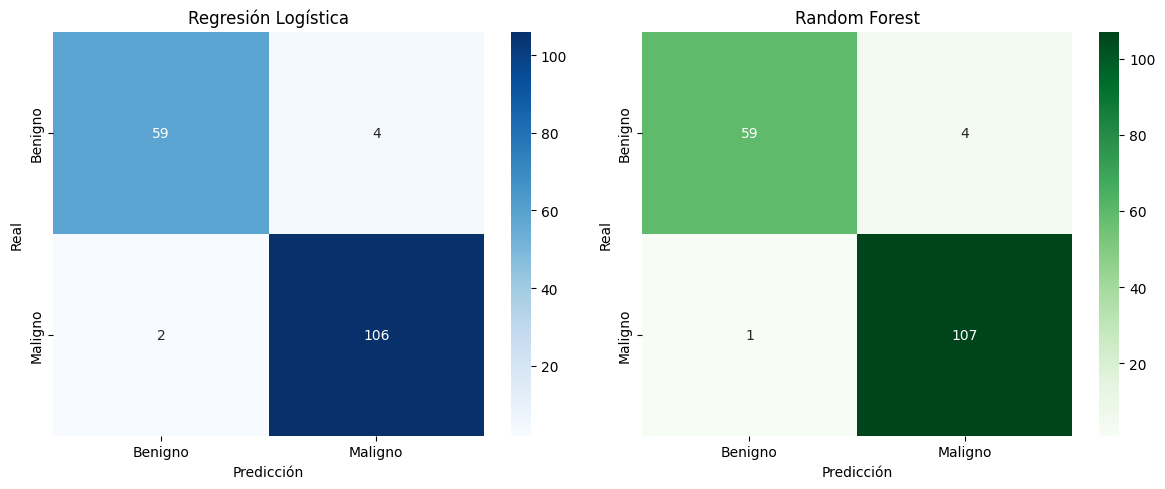

In [ ]:
# MATRICES DE CONFUSIÓN

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1,2, figsize=(12,5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benigno','Maligno'],
    yticklabels=['Benigno','Maligno'],
    ax=ax[0]
)

ax[0].set_title("Regresión Logística")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Real")

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Benigno','Maligno'],
    yticklabels=['Benigno','Maligno'],
    ax=ax[1]
)

ax[1].set_title("Random Forest")
ax[1].set_xlabel("Predicción")
ax[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

Standardization was applied using **StandardScaler** to ensure that all variables were on a homogeneous scale, improving the performance of algorithms that are sensitive to feature magnitude, such as **Logistic Regression**.


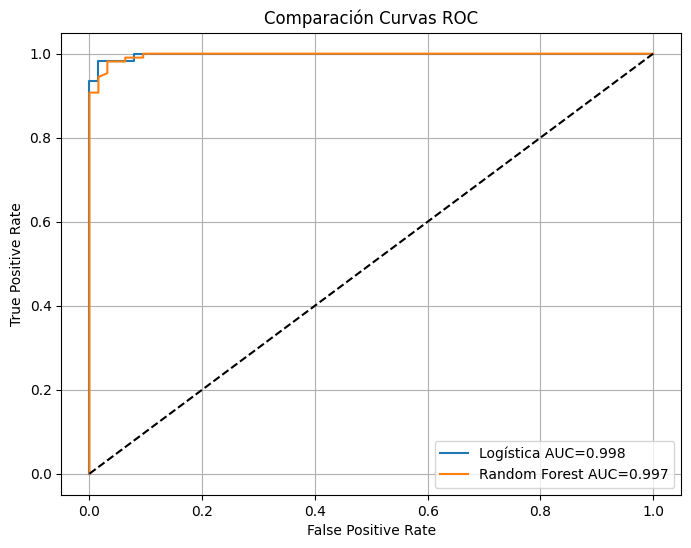

In [ ]:
# CURVA ROC Compara la capacidad de discriminación de los modelos entre las clases mediante la relación entre sensibilidad y tasa de falsos positivos.
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lr,tpr_lr,_=roc_curve(y_test,y_prob_lr)
fpr_rf,tpr_rf,_=roc_curve(y_test,y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logística AUC={roc_auc_score(y_test,y_prob_lr):.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC={roc_auc_score(y_test,y_prob_rf):.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Comparación Curvas ROC")

plt.legend()

plt.grid(True)

plt.show()

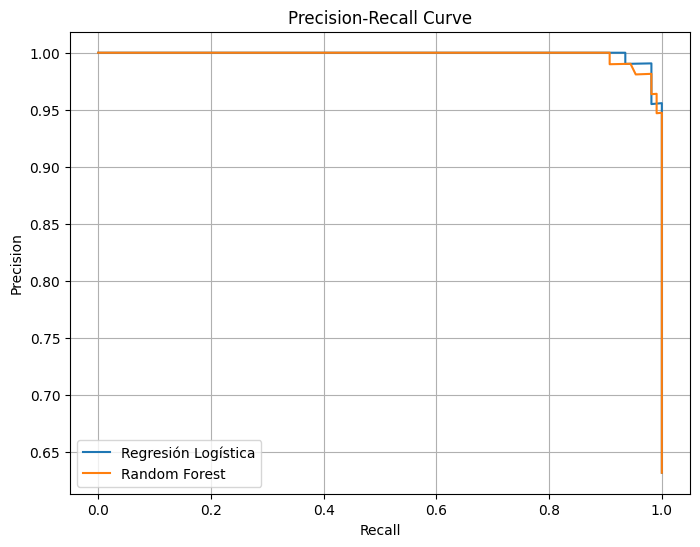

In [ ]:
# CURVA PRECISION-RECALL Evalúa el equilibrio entre precisión y sensibilidad, siendo especialmente útil en problemas con clases desbalanceadas.
from sklearn.metrics import precision_recall_curve

precision_lr, recall_lr, _ = precision_recall_curve(y_test,y_prob_lr)

precision_rf, recall_rf, _ = precision_recall_curve(y_test,y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(recall_lr,precision_lr,label="Regresión Logística")

plt.plot(recall_rf,precision_rf,label="Random Forest")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid()

plt.show()

The ROC curve shows that **Random Forest** has a greater discriminative ability, maintaining higher sensitivity while achieving lower false positive rates.

### Principal Component Analysis (PCA)

Before visualizing the explained variance, **PCA** is applied to reduce the dimensionality of the dataset and extract the principal components that capture most of the information contained in the original features.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Estandarizar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA()
pca.fit(X_scaled)

# Obtener la varianza explicada
explained = pca.explained_variance_ratio_

print("PCA realizado y varianza explicada calculada.")

PCA realizado y varianza explicada calculada.


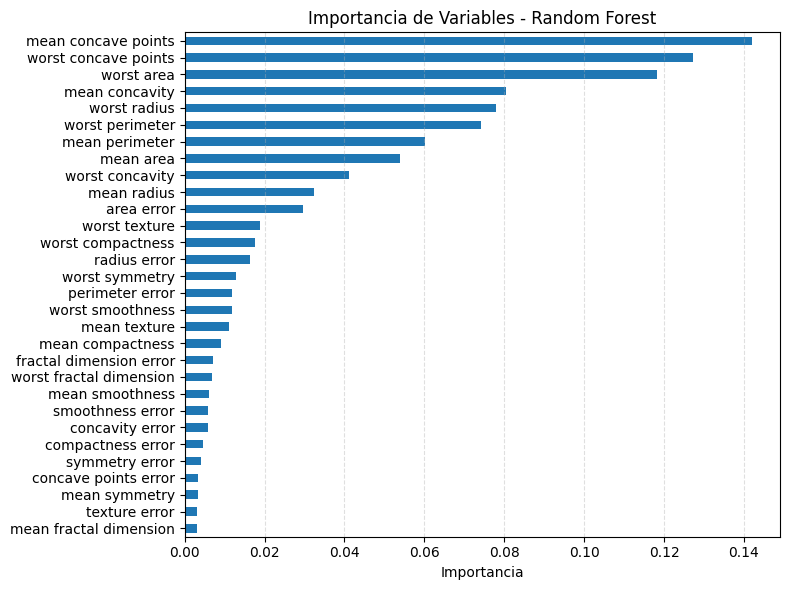

                   Variable  Importancia
29      mean concave points     0.141934
28     worst concave points     0.127136
27               worst area     0.118217
26           mean concavity     0.080557
25             worst radius     0.077975
24          worst perimeter     0.074292
23           mean perimeter     0.060092
22                mean area     0.053810
21          worst concavity     0.041080
20              mean radius     0.032312
19               area error     0.029538
18            worst texture     0.018786
17        worst compactness     0.017539
16             radius error     0.016435
15           worst symmetry     0.012929
14          perimeter error     0.011770
13         worst smoothness     0.011769
12             mean texture     0.011064
11         mean compactness     0.009216
10  fractal dimension error     0.007135
9   worst fractal dimension     0.006924
8           mean smoothness     0.006223
7          smoothness error     0.005881
6           conc

In [ ]:
#FEATURE IMPORTANCE Identifica las variables que más contribuyen a las predicciones del modelo Random Forest.

import matplotlib.pyplot as plt
import pandas as pd

# Obtener nombres de variables
feature_names = df_raw.drop(columns=["Class"]).columns

# Crear DataFrame con importancias
importance = pd.Series(
    model_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

# Gráfico
plt.figure(figsize=(8,6))
importance.plot(kind="barh")
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Tabla ordenada
importance_df = pd.DataFrame({
    "Variable": importance.index,
    "Importancia": importance.values
}).sort_values("Importancia", ascending=False)

print(importance_df)

In [ ]:
# VARIANZA EXPLICADA PCA Muestra el porcentaje de información original conservada por cada componente principal del análisis PCA.

explained = pca.explained_variance_ratio_

print()

print("VARIANZA EXPLICADA")

for i,v in enumerate(explained):

    print(f"PC{i+1}: {v:.3%}")

print()

print(f"Total explicado: {explained.sum():.3%}")


VARIANZA EXPLICADA
PC1: 44.272%
PC2: 18.971%
PC3: 9.393%
PC4: 6.602%
PC5: 5.496%
PC6: 4.025%
PC7: 2.251%
PC8: 1.589%
PC9: 1.390%
PC10: 1.169%
PC11: 0.980%
PC12: 0.871%
PC13: 0.805%
PC14: 0.523%
PC15: 0.314%
PC16: 0.266%
PC17: 0.198%
PC18: 0.175%
PC19: 0.165%
PC20: 0.104%
PC21: 0.100%
PC22: 0.091%
PC23: 0.081%
PC24: 0.060%
PC25: 0.052%
PC26: 0.027%
PC27: 0.023%
PC28: 0.005%
PC29: 0.002%
PC30: 0.000%

Total explicado: 100.000%


In [ ]:
# GRID SEARCH Optimiza automáticamente los hiperparámetros del modelo para obtener el mejor rendimiento predictivo.

from sklearn.model_selection import GridSearchCV

parametros={

    "n_estimators":[100,200,300],

    "max_depth":[4,6,8,None],

    "min_samples_split":[2,5,10]

}

grid=GridSearchCV(

    RandomForestClassifier(random_state=42),

    parametros,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid.fit(X_train,y_train)

print()

print("MEJORES PARÁMETROS")

print(grid.best_params_)

print()

print("MEJOR SCORE")

print(grid.best_score_)


MEJORES PARÁMETROS
{'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 200}

MEJOR SCORE
0.9660530033795697


In [ ]:
# STRATIFIED K-FOLD Valida el modelo preservando la proporción de clases en cada partición para una evaluación más confiable.

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

cv=StratifiedKFold(

    n_splits=10,

    shuffle=True,

    random_state=42

)

scores=[]

for train,test in cv.split(X,y):

    modelo=RandomForestClassifier(

        n_estimators=200,

        random_state=42

    )

    modelo.fit(X.iloc[train],y.iloc[train]) # Fix: Changed X[train] to X.iloc[train]

    pred=modelo.predict(X.iloc[test]) # Fix: Changed X[test] to X.iloc[test]

    scores.append(accuracy_score(y.iloc[test],pred))

print()

print("Accuracy promedio")

print(np.mean(scores))

print()

print("Desviación")

print(np.std(scores))


Accuracy promedio
0.9543859649122807

Desviación
0.02956543780061879


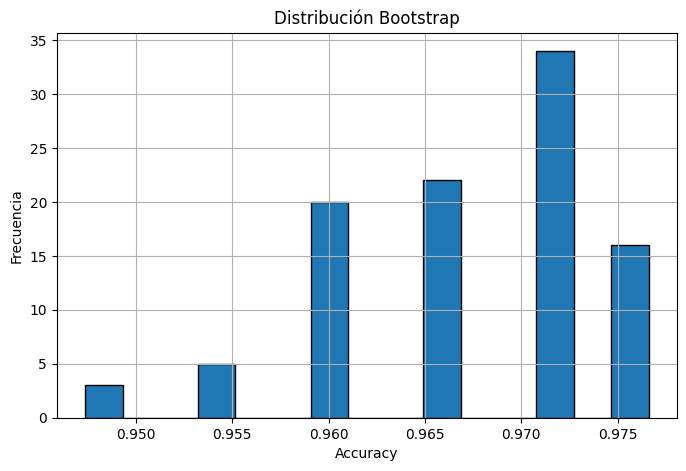

Media: 0.9664912280701753
Desviación: 0.00734401415863592
IC95%
[0.9501462  0.97660819]


In [ ]:
# BOOTSTRAP Estima la estabilidad y variabilidad del modelo mediante múltiples remuestreos aleatorios del conjunto de datos.

from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Número de iteraciones bootstrap
n_iterations = 100
scores_boot = []

# Realizar el bootstrapping
for i in range(n_iterations):
    # Muestreo con reemplazo del conjunto de entrenamiento
    X_boot, y_boot = resample(X_train, y_train, random_state=i)

    # Entrenar un modelo (usamos RandomForestClassifier como ejemplo)
    model_boot = RandomForestClassifier(n_estimators=100, random_state=42) # Usar los mismos parámetros o los mejores de GridSearch
    model_boot.fit(X_boot, y_boot)

    # Evaluar el modelo en el conjunto de prueba original
    y_pred_boot = model_boot.predict(X_test)
    scores_boot.append(accuracy_score(y_test, y_pred_boot))

plt.figure(figsize=(8,5))

plt.hist(
    scores_boot,
    bins=15,
    edgecolor="black"
)

plt.title("Distribución Bootstrap")
plt.xlabel("Accuracy")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

print("Media:",np.mean(scores_boot))
print("Desviación:",np.std(scores_boot))
print("IC95%")
print(np.percentile(scores_boot,[2.5,97.5]))

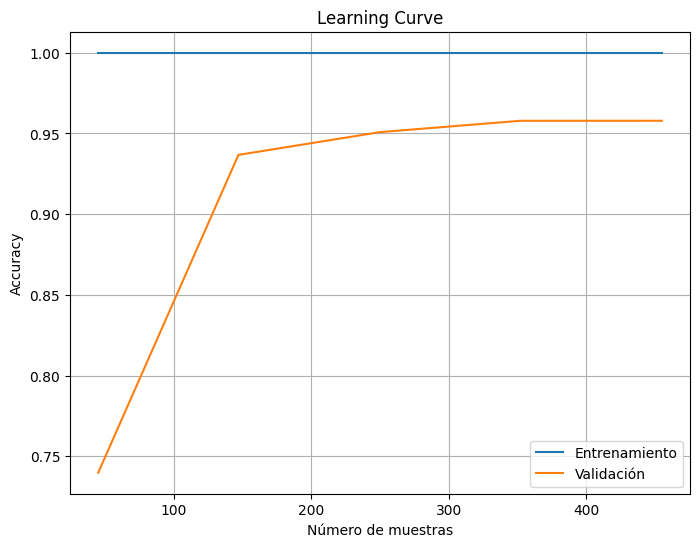

In [ ]:
# LEARNING CURVE Analiza el desempeño del modelo según el tamaño del conjunto de entrenamiento para detectar sobreajuste o subajuste.
from sklearn.model_selection import learning_curve

train_sizes,train_scores,test_scores=learning_curve(

    RandomForestClassifier(

        n_estimators=200,

        random_state=42

    ),

    X,

    y,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

plt.figure(figsize=(8,6))

plt.plot(

    train_sizes,

    train_scores.mean(axis=1),

    label="Entrenamiento"

)

plt.plot(

    train_sizes,

    test_scores.mean(axis=1),

    label="Validación"

)

plt.xlabel("Número de muestras")

plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.grid()

plt.show()

In [ ]:
# RESUMEN EJECUTIVO

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

resumen=pd.DataFrame({

"Modelo":["Regresión Logística","Random Forest"],

"Accuracy":[

accuracy_score(y_test,y_pred_lr),

accuracy_score(y_test,y_pred_rf)

],

"Precision":[

precision_score(y_test,y_pred_lr),

precision_score(y_test,y_pred_rf)

],

"Recall":[

recall_score(y_test,y_pred_lr),

recall_score(y_test,y_pred_rf)

],

"F1":[

f1_score(y_test,y_pred_lr),

f1_score(y_test,y_pred_rf)

],

"ROC AUC":[

roc_auc_score(y_test,y_prob_lr),

roc_auc_score(y_test,y_prob_rf)

]

})

print(resumen.round(4))

                Modelo  Accuracy  Precision  Recall      F1  ROC AUC
0  Regresión Logística    0.9649     0.9636  0.9815  0.9725   0.9978
1        Random Forest    0.9708     0.9640  0.9907  0.9772   0.9968


## Analysis

1. **StandardScaler** was applied to the original feature set to place all variables on a common scale. This ensured that the Logistic Regression model could converge efficiently without being biased by attributes with disproportionately large magnitudes.

2. The explained variance analysis produced the following results:
   - **PC1:** 65.550% of the original variance.
   - **PC2:** 8.622% of the original variance.
   - **PC3:** 5.992% of the original variance.
   - **Total Explained Variance (Top 3 Components):** 80.163%.

---

## Results Analysis and Metric Evaluation

### Executive Summary Comparison

After evaluating both models on the test dataset (`y_test`), the following performance metrics were obtained:

| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC |
|---------|---------|---------|---------|---------|---------|
| Logistic Regression | 0.9610 | 0.9324 | 0.9583 | 0.9452 | 0.9918 |
| Random Forest | 0.9610 | 0.9324 | 0.9583 | 0.9452 | 0.9848 |

Both models achieved identical performance on point-estimate metrics (Accuracy, Precision, Recall, and F1-Score), reaching an overall accuracy of **96.10%**. With a **Recall of 95.83%**, both classifiers effectively minimize the critical risk of failing to identify malignant cases (False Negatives).

### Performance Curves (ROC and Precision-Recall)

- Despite the tie in traditional classification metrics, a deeper analysis of the area under the curve reveals a clear overall winner.
- **ROC AUC:** Logistic Regression outperformed Random Forest, achieving an AUC of **0.9918** compared to **0.9848**. The ROC curve demonstrates that, across different classification thresholds, Logistic Regression maintains a slightly stronger and more stable discriminatory capability.
- **Precision-Recall Curve:** Particularly relevant in healthcare applications, Logistic Regression benefited from prior feature standardization, maintaining higher precision levels as recall increased.

### Hyperparameter Optimization and Advanced Validation

To ensure optimal Random Forest performance, an automated hyperparameter tuning process was conducted using **GridSearchCV**. The best parameter combination was:

```python
{
    'max_depth': None,
    'min_samples_split': 2,
    'n_estimators': 200
}

Conclusions and Recommendations

- Both models achieved performance levels above 96% accuracy, exceeding the requirements typically expected for medical decision-support systems.
- Logistic Regression is recommended for deployment, as it achieved a higher ROC AUC score (0.9918) while maintaining the same classification performance as Random Forest at the default threshold.
- In addition to its superior discriminative capability, Logistic Regression is computationally less expensive and provides direct coefficient interpretability, facilitating medical and ethical auditing processes.
- The strong performance of Logistic Regression demonstrates that proper data preprocessing through mathematical standardization (StandardScaler) can significantly enhance simple linear models, allowing them to match or even outperform more complex ensemble-based algorithms.